In [1]:
#importing required libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance

import joblib

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Loadin dataset
import pandas as pd

DATA_PATH = "../data/raw/student-mat.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)


Dataset loaded successfully.
Shape: (395, 33)


In [3]:
# Looking at the dataset
df.head()
# df.tail()
# df.shape
# df.info()
# df.columns.tolist()
# df.info

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
#Check missing values

# missing_val=df.isnull().sum()
# print(missing_val)

#missing percentage

missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

print(missing_percentage)

school        0.0
sex           0.0
age           0.0
address       0.0
famsize       0.0
Pstatus       0.0
Medu          0.0
Fedu          0.0
Mjob          0.0
Fjob          0.0
reason        0.0
guardian      0.0
traveltime    0.0
studytime     0.0
failures      0.0
schoolsup     0.0
famsup        0.0
paid          0.0
activities    0.0
nursery       0.0
higher        0.0
internet      0.0
romantic      0.0
famrel        0.0
freetime      0.0
goout         0.0
Dalc          0.0
Walc          0.0
health        0.0
absences      0.0
G1            0.0
G2            0.0
G3            0.0
dtype: float64


In [5]:
#checking if there are any duplicate rows duplicate row

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# checking data types
print(df.dtypes)

Number of duplicate rows: 0
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object


In [6]:
# checking statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,395.0,16.696203,1.276043,15.0,16.0,17.0,18.0,22.0
Medu,395.0,2.749367,1.094735,0.0,2.0,3.0,4.0,4.0
Fedu,395.0,2.521519,1.088201,0.0,2.0,2.0,3.0,4.0
traveltime,395.0,1.448101,0.697505,1.0,1.0,1.0,2.0,4.0
studytime,395.0,2.035443,0.839240,1.0,1.0,2.0,2.0,4.0
failures,395.0,0.334177,0.743651,0.0,0.0,0.0,0.0,3.0
famrel,395.0,3.944304,0.896659,1.0,4.0,4.0,5.0,5.0
freetime,395.0,3.235443,0.998862,1.0,3.0,3.0,4.0,5.0
goout,395.0,3.108861,1.113278,1.0,2.0,3.0,4.0,5.0
Dalc,395.0,1.481013,0.890741,1.0,1.0,1.0,2.0,5.0


G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64


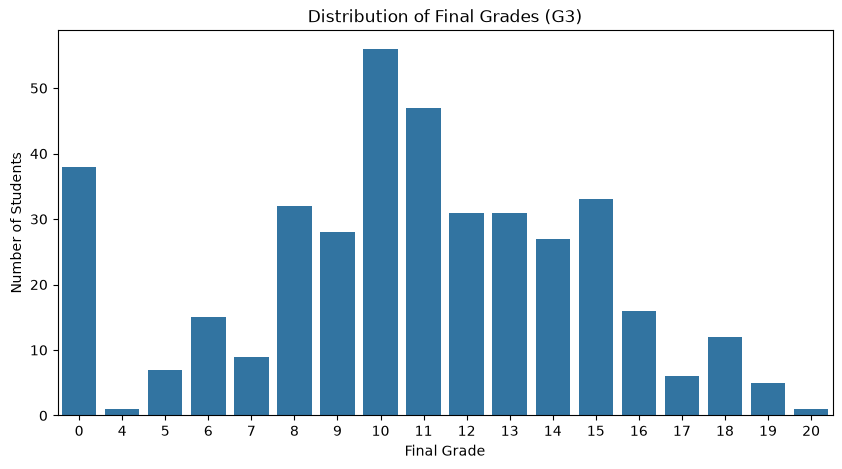

In [7]:
import matplotlib.pyplot as plt

import seaborn as sns
# Checking target grade 
print(df["G3"].value_counts().sort_index())

#plot target grade
 
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="G3"
)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

In [8]:
import matplotlib
print(matplotlib.__version__)

3.11.1


In [9]:
# creating classification target 
df["pass"] = (df["G3"] >= 10).astype(int)

print(df['pass'].value_counts())

#percentage
print(df['pass'].value_counts().mul(100).round(2))


pass
1    265
0    130
Name: count, dtype: int64
pass
1    26500
0    13000
Name: count, dtype: int64


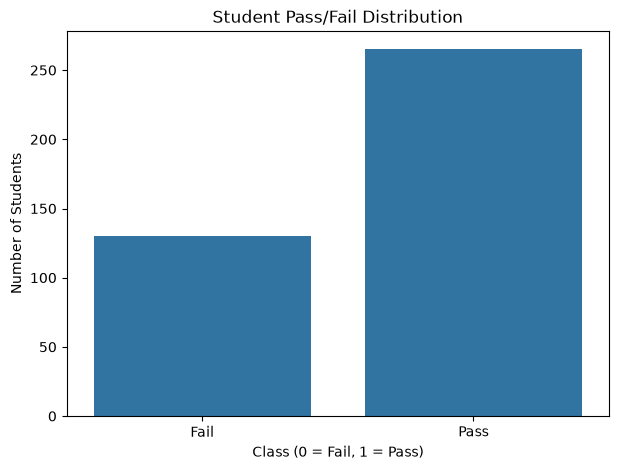

In [10]:
# visualizing target
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="pass"
)

plt.title("Student Pass/Fail Distribution")
plt.xlabel("Class (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.xticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.show()

In [11]:
# checking target Balance
class_distribution = (
    df["pass"]
    .value_counts()
    .rename(index={
        0: "Fail",
        1: "Pass"
    })
)

print(class_distribution)

#percentage of target balance
class_percentage = (
    df["pass"]
    .value_counts(normalize=True)
    .mul(100)
    .rename(index={
        0: "Fail",
        1: "Pass"
    })
)

print(class_percentage)


pass
Pass    265
Fail    130
Name: count, dtype: int64
pass
Pass    67.088608
Fail    32.911392
Name: proportion, dtype: float64


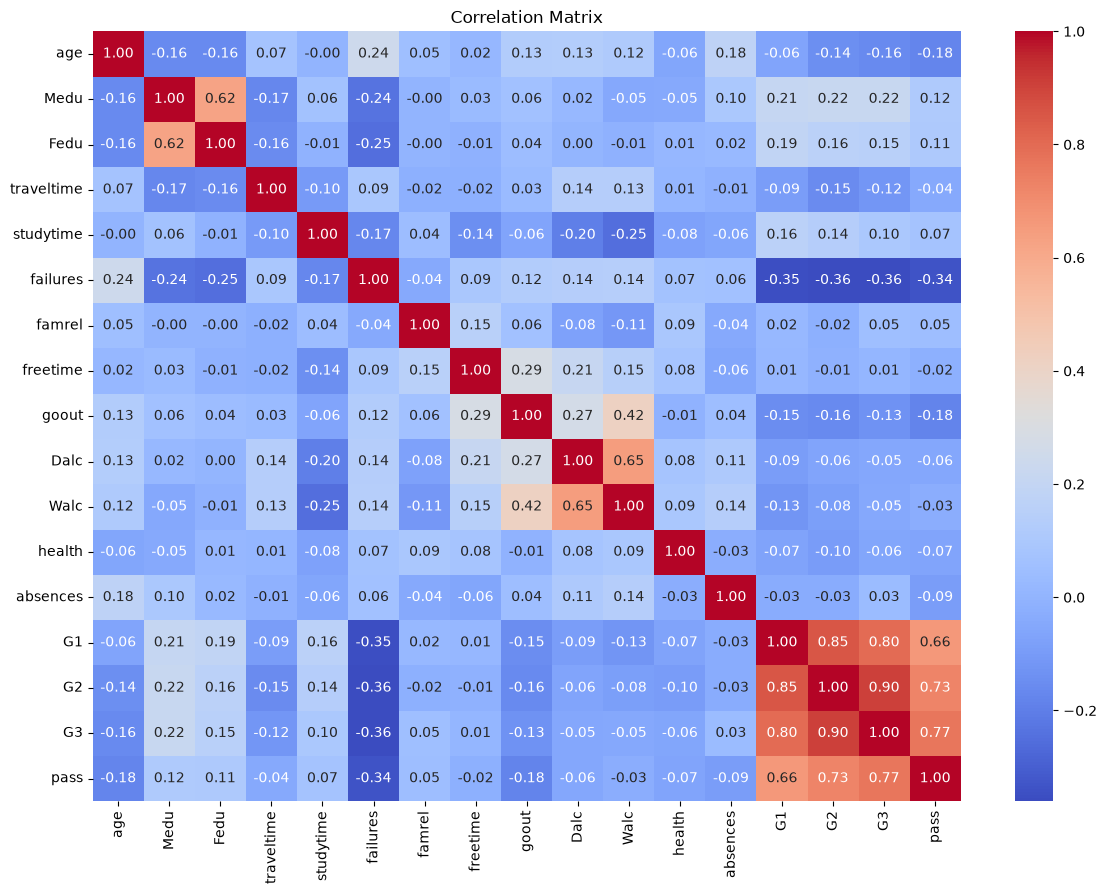

In [12]:
# Feature relationship --> G1 and G2 have strong relationship with G3 that's why we remove this
import numpy as np
numeric_columns = df.select_dtypes(
    include=np.number
).columns

correlation = df[numeric_columns].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

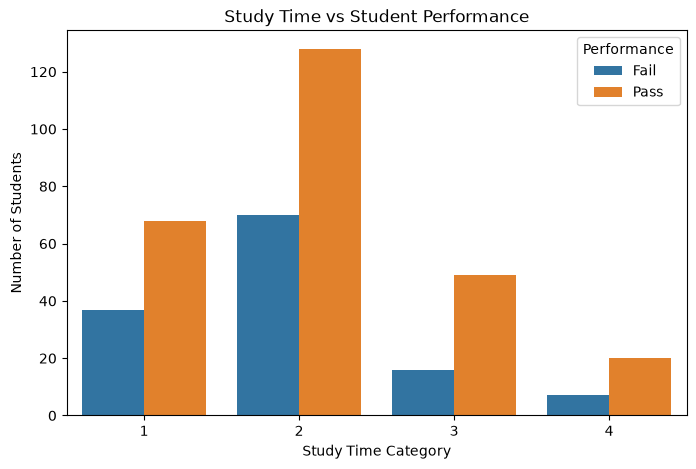

In [13]:
# study time vs performance
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="studytime",
    hue="pass"
)

plt.title("Study Time vs Student Performance")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.legend(
    title="Performance",
    labels=["Fail", "Pass"]
)

plt.show()

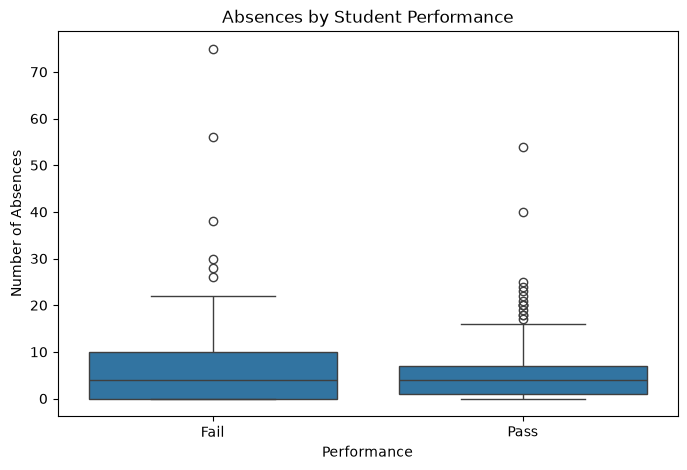

In [14]:
# Absences vs perfromance
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="pass",
    y="absences"
)

plt.title("Absences by Student Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Absences")

plt.xticks(
    [0, 1],
    ["Fail", "Pass"]
)

plt.show()

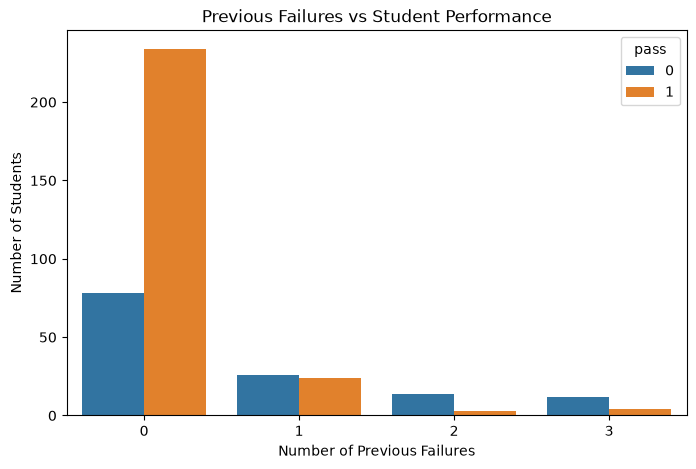

In [15]:
# Failure vs performance
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="failures",
    hue="pass"
)

plt.title("Previous Failures vs Student Performance")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

In [16]:
# cleaning the data


#age
print(df['age'].min())
print(df["age"].max())

assert df["age"].between(15, 22).all()
# G3
assert df['G3'].between(0,20).all()
#absence
assert (df["absences"]>=0).all()

#binary variables
print(df["sex"].unique())
print(df["internet"].unique())
print(df["higher"].unique())


15
22
<StringArray>
['F', 'M']
Length: 2, dtype: str
<StringArray>
['no', 'yes']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str


In [17]:
# define features and target
TARGET = "pass"

DROP_COLUMNS = [
    "G1",
    "G2",
    "G3",
    "pass"
]

X = df.drop(columns=DROP_COLUMNS)

y = df[TARGET]

print("X shape: " ,X.shape)
print("y shape: " ,y.shape)

X shape:  (395, 30)
y shape:  (395,)


In [18]:
# identify neaumerical adn categoriacl feature
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)



Numerical features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Categorical features:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [19]:
# Train / Test split (we need to split before fitting preprocessing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


# verifying split
print("Training distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True))

Training data: (316, 30)
Testing data: (79, 30)
Training distribution:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64

Testing distribution:
pass
1    0.670886
0    0.329114
Name: proportion, dtype: float64


# Preprocessing pipelines

In [20]:
#neumerinc pipeline
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer



numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

#cetagorical pipeline
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# combint two with together
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)


### viva explaination: "We used a preprocessing pipeline so that imputation, scaling and encoding are learned only from the training data. This prevents information leakage from the test set."


In [21]:
# Baseline model --> Our baseline is a majority-class classirier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
  
    f1_score,

)

baseline_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

# Train
baseline_model.fit(
    X_train,
    y_train
)

#Predict

baseline_pred=baseline_model.predict(X_test)

# Evaluate
baseline_accuracy = accuracy_score(
    y_test,
    baseline_pred
)

baseline_f1 = f1_score(
    y_test,
    baseline_pred
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline F1:", baseline_f1)



Baseline Accuracy: 0.6708860759493671
Baseline F1: 0.803030303030303


In [22]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)
            
#Train
logistic_model.fit(
    X_train,
    y_train
)

#Predict
logistic_pred=logistic_model.predict(X_test)


In [23]:
#KNN model -->(our main model)

knn_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            KNeighborsClassifier()
        )
    ]
)

In [24]:
# kNN Htper perameter domain 

knn_param_grid = {
    "classifier__n_neighbors": [
        3, 5, 7, 9, 11, 13, 15, 17, 19
    ],
    
    "classifier__weights": [
        "uniform",
        "distance"
    ],
    
    "classifier__metric": [
        "euclidean",
        "manhattan"
    ]
}

# create CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

#Grid search

knn_grid=GridSearchCV(

    estimator=knn_model,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    return_train_score=True
)

#Train
knn_grid.fit(
    X_train,
    y_train
)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__metric': ['euclidean', 'manhattan'], 'classifier__n_neighbors': [3, 5, ...], 'classifier__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_param

In [25]:
#Best KNN parameters
print("Best Parameters:")
print(knn_grid.best_params_)

#Best cv score

print("Best cross validation F1:",
knn_grid.best_score_
)

#Get final model
best_knn=knn_grid.best_estimator_


Best Parameters:
{'classifier__metric': 'euclidean', 'classifier__n_neighbors': 13, 'classifier__weights': 'uniform'}
Best cross validation F1: 0.8169381809405545


In [26]:
# Random Forest
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

# Parameter grid

rf_param_grid = {
    "classifier__n_estimators": [
        100,
        200
    ],
    
    "classifier__max_depth": [
        None,
        5,
        10
    ],
    
    "classifier__min_samples_split": [
        2,
        5
    ]
}

#Grid search
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

#Train
rf_grid.fit(
    X_train,
    y_train
)

#Best Parameter
print(rf_grid.best_params_)

# Bst model
best_rf=rf_grid.best_estimator_


{'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}


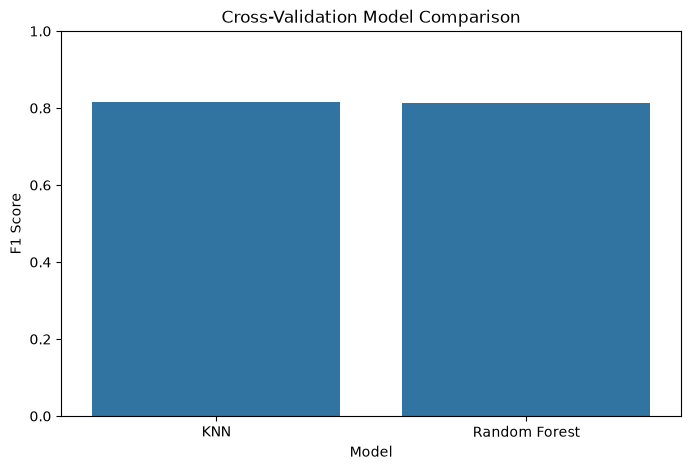

In [27]:
# compare cross-validaton Results

cv_results = pd.DataFrame({
    "Model": [
        "KNN",
        "Random Forest"
    ],
    
    "Best CV F1": [
        knn_grid.best_score_,
        rf_grid.best_score_
    ]
})

cv_results


#plot
plt.figure(figsize=(8, 5))

sns.barplot(
    data=cv_results,
    x="Model",
    y="Best CV F1"
)

plt.title("Cross-Validation Model Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.show()


In [28]:
# Final Test Evaluation -->(Untouched test model)

models={
    "Baseline":baseline_model,
    "Logistic Regression":logistic_model,
    "KNN":best_knn,
    "Random Forest":best_rf
}

#Train logistic regrassion
logistic_model.fit(
    X_train,
    y_train
)

# All models
results = []

for name, model in models.items():
    
    if name != "Baseline" and name != "KNN" and name != "Random Forest":
        model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
  "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

    # Create comparision table
    results_df=pd.DataFrame(results)
    results_df

        



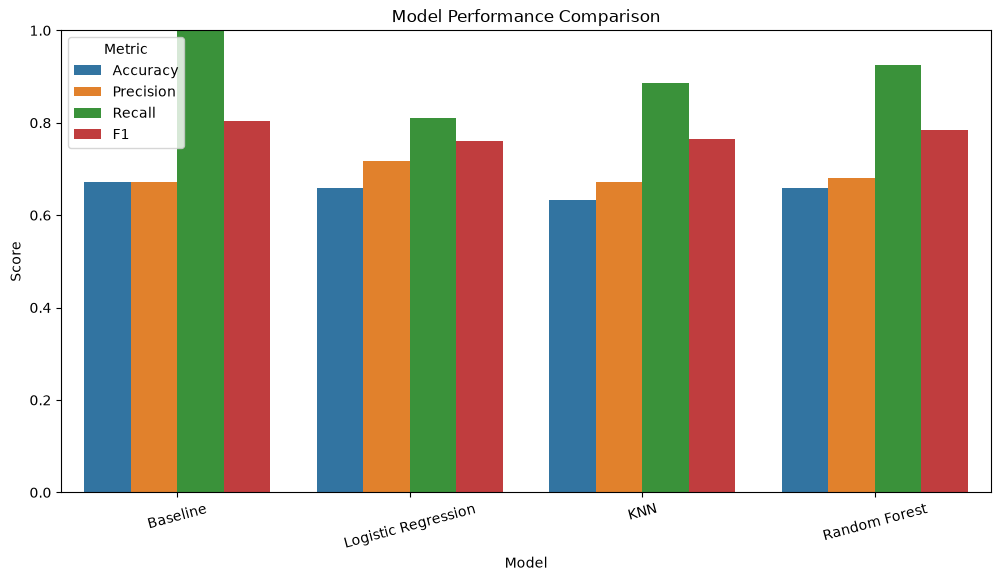

In [29]:
# Model comparison chart
results_melted = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    var_name="Metric",
    value_name="Score"
)

# Printing the value

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.xticks(rotation=15)

plt.show()

In [30]:
# KNN classification report

knn_predictions = best_knn.predict(X_test)

print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=[
            "Fail",
            "Pass"
        ]
    )
)



              precision    recall  f1-score   support

        Fail       0.33      0.12      0.17        26
        Pass       0.67      0.89      0.76        53

    accuracy                           0.63        79
   macro avg       0.50      0.50      0.47        79
weighted avg       0.56      0.63      0.57        79



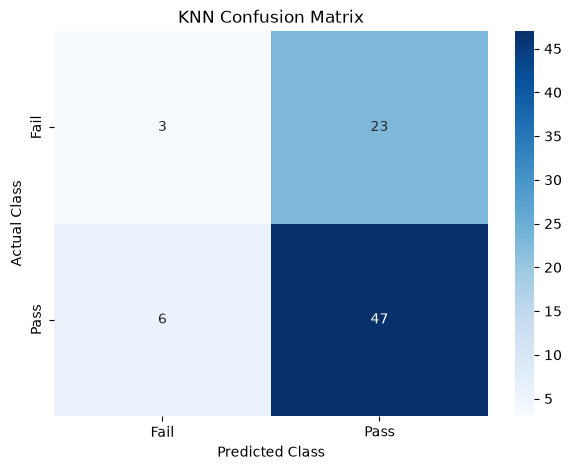

In [31]:
# KNN confusion Matrix
cm = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


In [32]:
# Roc- AUC
knn_probabilities = best_knn.predict_proba(
    X_test
)[:, 1]

knn_auc = roc_auc_score(
    y_test,
    knn_probabilities
)

print("KNN ROC-AUC:", knn_auc)

KNN ROC-AUC: 0.5878084179970973


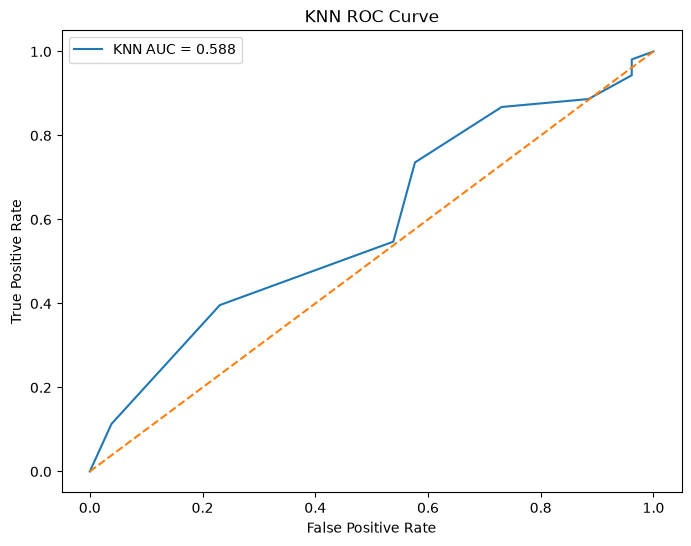

In [33]:
#ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    knn_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"KNN AUC = {knn_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("KNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()


Average Precision: 0.7372434909590334


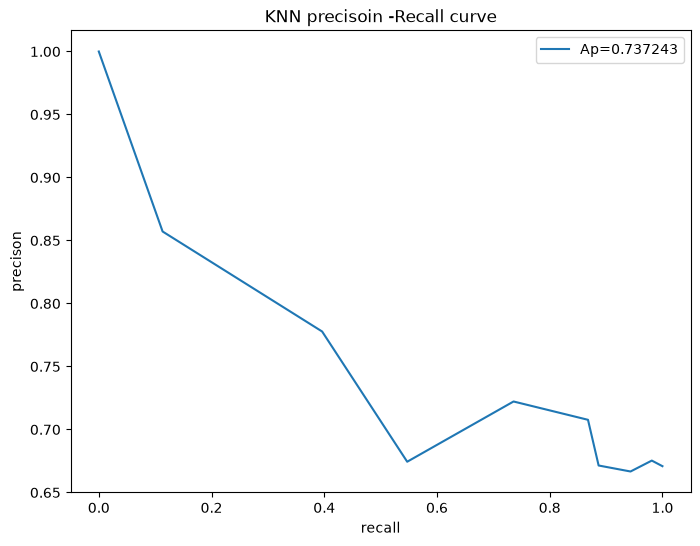

In [ ]:
# Precision recall curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    knn_probabilities
)

average_precision = average_precision_score(
    y_test,
    knn_probabilities
)

print(
    "Average Precision:",
    average_precision
)

# plot
plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"Ap={average_precision:3f}"
)
plt.title("KNN precisoin -Recall curve")
plt.xlabel("recall")
plt.ylabel("precison")

plt.legend()
plt.show()


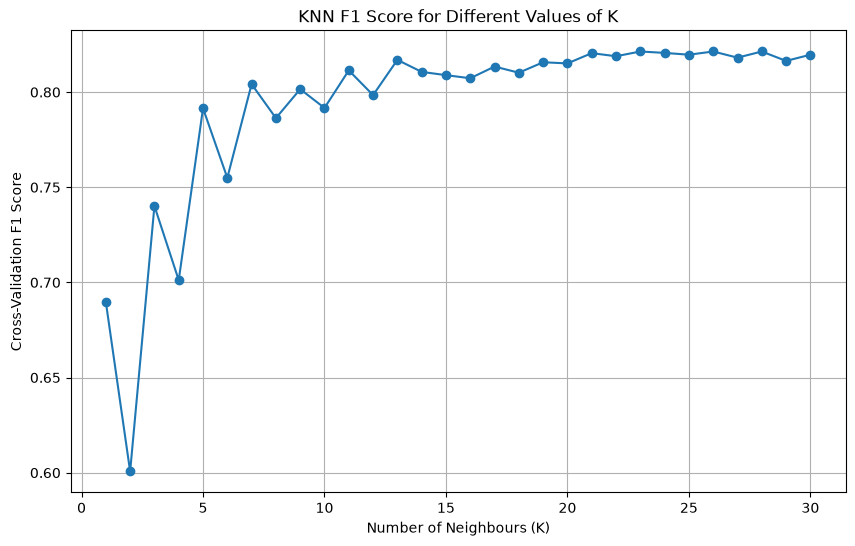

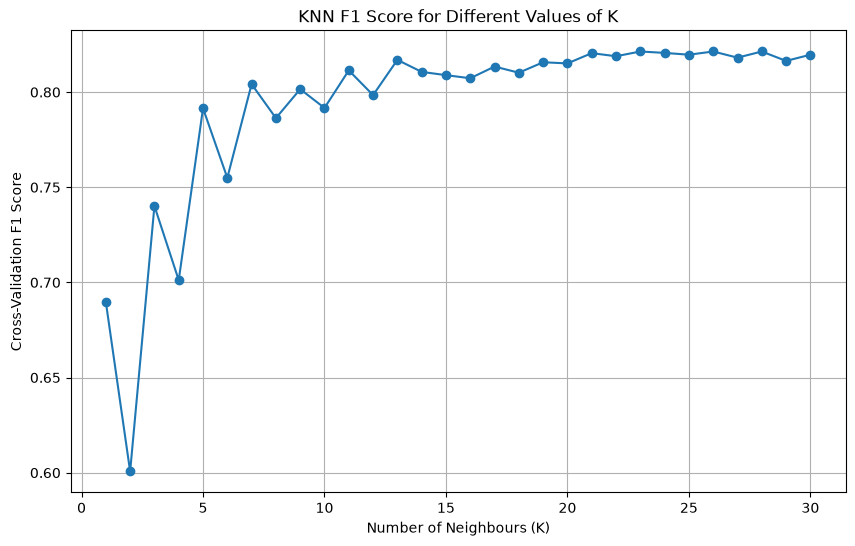

In [35]:
# Find the best k

k_values = range(1, 31)

k_scores = []

for k in k_values:
    
    model = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=k
                )
            )
        ]
    )

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    )
    
    k_scores.append(
        scores["test_score"].mean()
    )

#plot

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    k_scores,
    marker="o"
)

plt.title("KNN F1 Score for Different Values of K")
plt.xlabel("Number of Neighbours (K)")
plt.ylabel("Cross-Validation F1 Score")

plt.grid(True)

plt.show()

# Find best
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    k_scores,
    marker="o"
)

plt.title("KNN F1 Score for Different Values of K")
plt.xlabel("Number of Neighbours (K)")
plt.ylabel("Cross-Validation F1 Score")

plt.grid(True)

plt.show()



In [36]:
# Error analysis
error_analysis = X_test.copy()

error_analysis["actual"] = y_test.values

error_analysis["predicted"] = knn_predictions

error_analysis["correct"] = (
    error_analysis["actual"]
    ==
    error_analysis["predicted"]
)

# view incorrect prediction

errors = error_analysis[
    error_analysis["correct"] == False
]

print("Number of incorrect predictions:", len(errors))

errors.head()

Number of incorrect predictions: 29


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,actual,predicted,correct
225,GP,F,18,R,GT3,T,3,1,other,other,...,5,3,3,1,1,4,16,0,1,False
307,GP,M,19,U,GT3,T,4,4,teacher,services,...,4,3,4,1,1,4,38,0,1,False
67,GP,F,16,U,GT3,T,3,1,services,other,...,4,3,3,1,2,5,4,0,1,False
255,GP,M,17,U,LE3,T,1,1,health,other,...,4,4,4,1,2,5,2,0,1,False
86,GP,F,16,U,LE3,T,2,2,at_home,other,...,4,3,4,1,2,2,4,0,1,False


In [37]:
# False Negative
false_negatives=error_analysis[
    (error_analysis["actual"]==1) & (error_analysis["predicted"]==0)]

print("false Negative",len(false_negatives))

false Negative 6


In [38]:
# false positive
false_positives = error_analysis[
    (error_analysis["actual"] == 0) &
    (error_analysis["predicted"] == 1)
]

print(
    "False Positives:",
    len(false_positives)
)

False Positives: 23


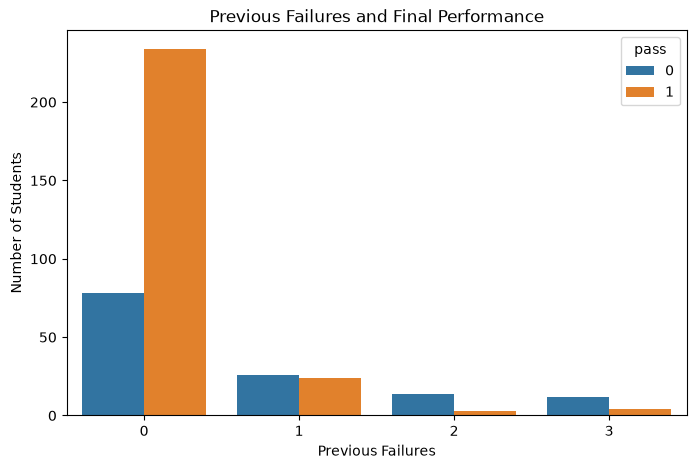

In [39]:
# Analyze failures
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="failures",
    hue="pass"
)

plt.title("Previous Failures and Final Performance")
plt.xlabel("Previous Failures")
plt.ylabel("Number of Students")

plt.show()

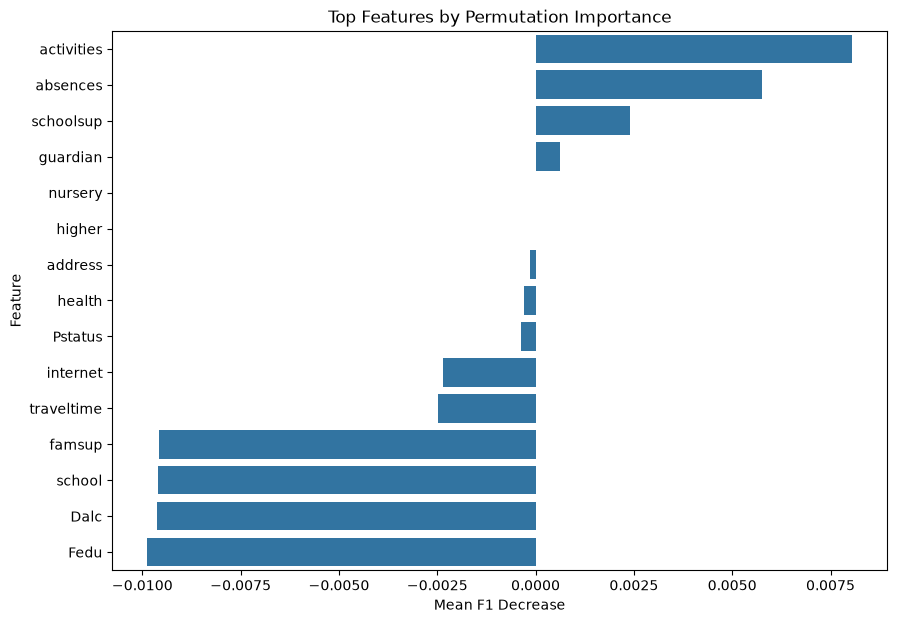

In [41]:
#permutation importance
perm = permutation_importance(
    best_knn,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
# create dataframe
feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

# plot
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Features by Permutation Importance")
plt.xlabel("Mean F1 Decrease")
plt.ylabel("Feature")

plt.show()



In [48]:
# save model
MODEL_PATH = "../results/knn_student_performance_model.joblib"

joblib.dump(
    best_knn,
    MODEL_PATH
)

print("Model saved successfully.")

Model saved successfully.


In [49]:
# Load model
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_predictions = loaded_model.predict(
    X_test
)

print(
    "Loaded model F1:",
    f1_score(
        y_test,
        loaded_predictions
    )
)

Loaded model F1: 0.7642276422764228


In [50]:
# save result
results_df.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Results saved.")

Results saved.


In [51]:
# Save KNN Result

knn_results = {
    "accuracy": accuracy_score(
        y_test,
        knn_predictions
    ),
    
    "precision": precision_score(
        y_test,
        knn_predictions
    ),
    
    "recall": recall_score(
        y_test,
        knn_predictions
    ),
    
    "f1": f1_score(
        y_test,
        knn_predictions
    ),
    
    "roc_auc": knn_auc,
    
    "best_k": best_knn.named_steps[
        "classifier"
    ].n_neighbors
}


In [53]:
# Save matrix
metrics_df = pd.DataFrame(
    [knn_results]
)

metrics_df.to_csv(
    "../results/metrics/knn_metrics.csv",
    index=False
)

In [47]:
import sklearn
import pandas
import numpy
import matplotlib
import seaborn

print("Python environment information")
print("--------------------------------")

print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)
print("Random State:", RANDOM_STATE)

Python environment information
--------------------------------
NumPy: 2.5.1
Pandas: 3.0.5
Scikit-learn: 1.9.0
Matplotlib: 3.11.1
Seaborn: 0.13.2
Random State: 42
